In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
mpg = sns.load_dataset("mpg")

In [2]:
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Create a visual showing the relationship between horsepower and fuel economy.

##### Weight is a continuous variable, new weight category column created, assigning weights into distinct categories for visualisation using the qcut() method.

In [6]:
mpg['weight_category'] = pd.qcut(
    mpg['weight'],
    q=3,
    labels=['Light', 'Medium', 'Heavy']
)

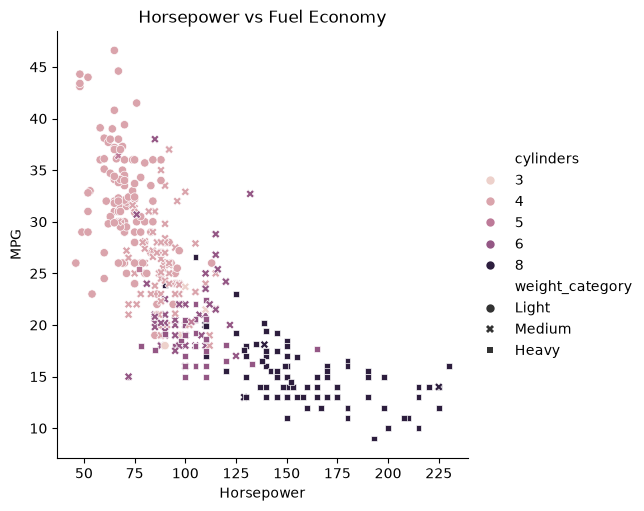

In [4]:
sns.relplot(data=mpg, x='horsepower', y='mpg', style='weight_category', hue='cylinders')
plt.title('Horsepower vs Fuel Economy')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.show()

#### Observations: There is a general negative relationship between horsepower and fuel economy: as horsepower increases, MPG tends to decrease.
#### Higher-horsepower vehicles also tend to have more cylinders and greater weight.
#### Heavier cars have more power and cylinders but the trade off is lower fuel economy overall and vice versa applies. 
#### This suggests that vehicle weight and number of cylinders may be associated with the relationship between horsepower and fuel economy.

## Create a table summarizing fuel economy by country of origin

In [3]:
econ = mpg.groupby(by='origin').agg({'mpg':'mean','displacement':'mean', 'cylinders':'mean', 'weight':'mean'})

In [10]:
econdf = econ.reset_index()

In [11]:
econdf

,origin,mpg,displacement,cylinders,weight
0,europe,27.891429,109.142857,4.157143,2423.300000
1,japan,30.450633,102.708861,4.101266,2221.227848
2,usa,20.083534,245.901606,6.248996,3361.931727


#### Observations: USA - higher displacement, number of cylinders and heavier vehicles compared to european and japanese vehicles. 
#### Japan's cars have greater fuel economy but lower in all other metrics. 
#### While cylinders and displacement are only slightly increased between europe and japan, the extra 200 units difference in weight seem to lean towards weight having a more significant impact on mpg than displacement and cylinders differing from around 27.8 and 30.4mpg.  

## Create a visual showing how fuel economy has changed over time

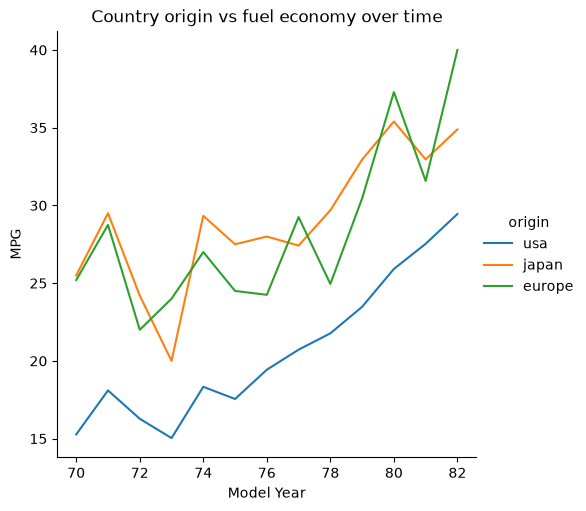

In [23]:
sns.relplot(data=mpg, x= 'model_year', y='mpg', kind='line', hue='origin', errorbar=None)
plt.title('Country origin vs fuel economy over time')
plt.xlabel('Model Year')
plt.ylabel('MPG')
plt.show()

#### Observations: There is a consistent trend among all the origins where newer models have improved mpg over time. 
#### Japan and Europe have a closer relationship compared to USA, japan surpassing europe in fuel economy most of the time apart from 77 and 80 models. 
#### There seems to be a Europe spike in mpg from the 82 model. 
#### From model year 75, USA has consistently and steadily increased their fuel economy over time despite lower than japan and europe overall. 
#### Significant drop in fuel economy for all counties between 72 and 74.   

## Create two other visuals or tables related to fuel economy.

### The following are additional visuals to investigate what may have contributed to changes in fuel economy 
#### Investigate does vehicle weight relate to fuel economy?

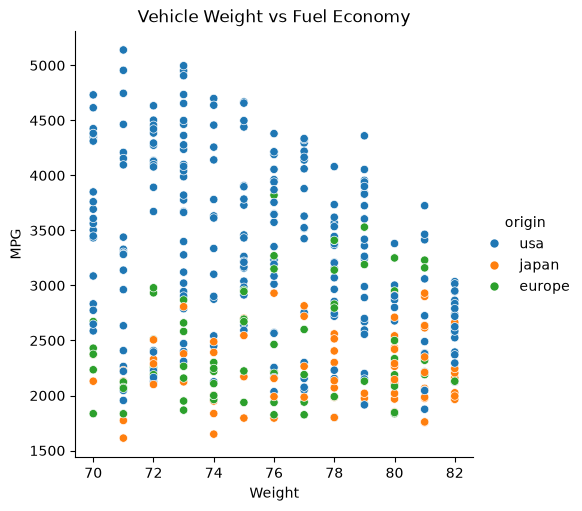

In [20]:
sns.relplot(data=mpg, x= 'model_year', y='weight', hue='origin', kind='scatter')
plt.title('Vehicle Weight vs Fuel Economy')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()

#### Observations: Across all countries, there is a downward trend as weight increases, mpg decreases. Heavier cars tend to have lower fuel economy, not going above much over 3000mpg for the heaviest vehicles. 

### Investigate how does fuel economy vary between cars with different numbers of cylinders?

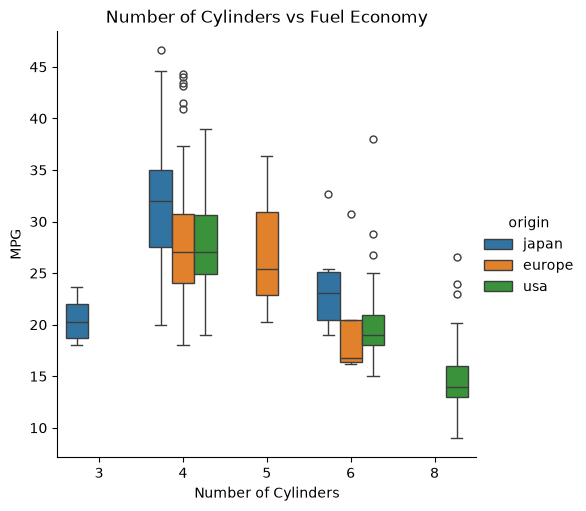

In [19]:
sns.catplot(data=mpg, x= 'cylinders', y='mpg', hue='origin', kind='box')
plt.title('Number of Cylinders vs Fuel Economy')
plt.xlabel('Number of Cylinders')
plt.ylabel('MPG')
plt.show()

#### Observations: 4 cylinders has the widest range of possible mpg values. 
#### 6 cylinder has a more narrow range of values with the most outliers. Europe has the most outliers for their 4 cylinder models. 
#### 3 cylinders the most narrow range between 18 and 24mpg.
#### Vehicles with 4 cylinders have the greatest median values across all origins. USA median is around 32mpg for 4 while 8 cylinders the lowest (around 14mpg), which is nearly 50% less efficient going from 4 to 8.
#### In our dataset, Japan solely produces ranges of vehicles with the less than 4 cylinders and usa offers vehicles 8 cylinders, while europe sits between offering 4 to 6 cylinder vehicles. 

## Add comments to your notebook with your observations.